# Task 1 Exploratory Data Analysis
**MLCB 2026 Assignment #2**  
Heart Disease Classification using Repeated Nested Cross-Validation

Name: Εvangelia Kourtzelli 
Email:evakourtz@gmail.com


### Feature description
The dataset contains 242 patient records and 14 attributes (13 features + 1 target variable). The task is binary classification: predict whether a patient has heart disease based on the target variable num, where num = 0 indicates no heart disease and num = 1 indicates the presence of heart disease.

| Feature | Type | Description |
|---------|------|-------------|
| age | Continuous | Age in years |
| sex | Binary | Sex (1 = male, 0 = female) |
| cp | Categorical | Chest pain type (0–3): typical angina, atypical angina, non-anginal pain, asymptomatic |
| trestbps | Continuous | Resting blood pressure on admission (mm Hg) |
| chol | Continuous | Serum cholesterol (mg/dl) |
| fbs | Binary | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) |
| restecg | Categorical | Resting ECG results (0–2): normal, ST-T wave abnormality, left ventricular hypertrophy |
| thalach | Continuous | Maximum heart rate achieved during exercise |
| exang | Binary | Exercise-induced angina (1 = yes, 0 = no) |
| oldpeak | Continuous | ST depression induced by exercise relative to rest |
| slope | Categorical | Slope of the peak exercise ST segment (0–2) |
| ca | Ordinal | Number of major vessels (0–3) colored by fluoroscopy |
| thal | Categorical | Thalassemia type (1 = normal, 2 = fixed defect, 3 = reversible defect) |

The dataset also contains missing values.


All explanatory analysis functions are in `eda_utils.py`. We first load the dataset.  

In [1]:
import sys
sys.path.append("../src")
import eda_utils as eda

df = eda.load_data("../data/students_dataset.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,48.0,1.0,4.0,124.0,274.0,0.0,2.0,166.0,0.0,0.5,2.0,0.0,7.0,1
1,55.0,1.0,2.0,130.0,262.0,0.0,0.0,155.0,0.0,0.0,1.0,0.0,3.0,0
2,54.0,0.0,2.0,132.0,288.0,1.0,2.0,159.0,1.0,0.0,1.0,1.0,3.0,0
3,54.0,1.0,2.0,108.0,309.0,0.0,0.0,156.0,0.0,0.0,1.0,0.0,7.0,0
4,57.0,0.0,4.0,140.0,241.0,0.0,0.0,123.0,1.0,0.2,2.0,0.0,7.0,1


## 1. Dataset Overview 
Then we find the size and shape of the dataset, the types of the columns are , and what they  look like in terms of central tendency and spread.The reason all columns appear as numbers is becase categorical variables are encoded as numbers.

In [2]:
eda.show_overview(df)

Shape: (242, 14)

Dtypes:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
num           int64
dtype: object


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,241.000000,241.000000,242.000000
mean,54.549587,0.681818,3.152893,130.958678,249.838843,0.144628,0.979339,149.962810,0.326446,0.999174,1.586777,0.609959,4.713693,0.458678
std,8.996981,0.466736,0.975516,17.622551,52.846867,0.352454,0.999786,22.686449,0.469885,1.122940,0.613397,0.883497,1.948552,0.499322
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,2.250000,120.000000,212.000000,0.000000,0.000000,134.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,244.500000,0.000000,0.000000,153.500000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,277.750000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


### Missing values

Next step was to identify the  missing values in our dtaset. Later we wil proceed with the Imputation, which will happen inside each cross-validation fold, so that statistics computed from training data never leak into validation/test data. In the data missing values  are only observed  in 'ca' and 'thal', as we can see below.

In [3]:
eda.show_missing(df)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          1
thal        1
num         0
dtype: int64

### Duplicate rows

Exact duplicates  should be removed becase it can infuence  performance metrics if the same patient ends up in both training and test folds. We just count them here and flag for review, but the results is none. 

In [4]:
eda.show_duplicates(df)

np.int64(0)

### Outliers (only for continuous features)

We use the standard 1.5 × IQR rule to count potential outliers per continuous feature.

In [5]:
eda.show_outliers(df)

age: 0 outliers
trestbps: 6 outliers
chol: 5 outliers
thalach: 1 outliers
oldpeak: 4 outliers


### Class balance

Based on the class distribution we will follow different strategies.
1. **Folding strategy** If the classes are imbalanced, we must use `StratifiedKFold` so each fold reflects the overall class proportions.
2. **Metrics**. As we know making decisions based in  plain accuracy  metric can be misleading on imbalanced data. We will lead with **MCC**, **balanced accuracy**, **PR-AUC**, **F1**, and **recall**.

num
0    131
1    111
Name: count, dtype: int64


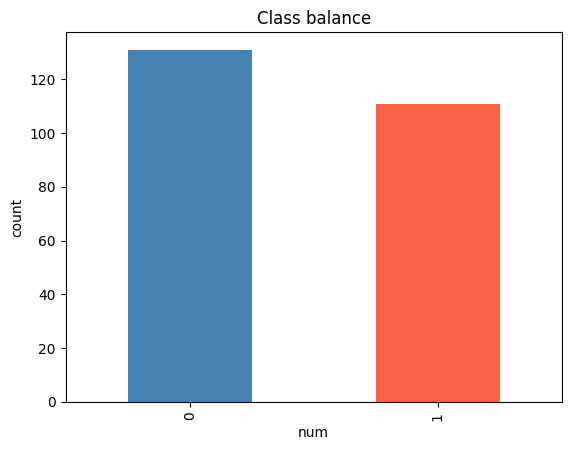

In [6]:
eda.plot_class_balance(df)

## 2. Feature Visualization

Now we look at the features themselves: how they're distributed, how they differ between healthy and diseased patients, how they relate to each other, and whether the two classes separate at all in a low-dimensional projection.

### Boxplots of continuous features by class

Boxplots show distribution shape, central tendency, spread, and outliers, split by target. Features whose boxes shift noticeably between classes are likely informative for prediction.

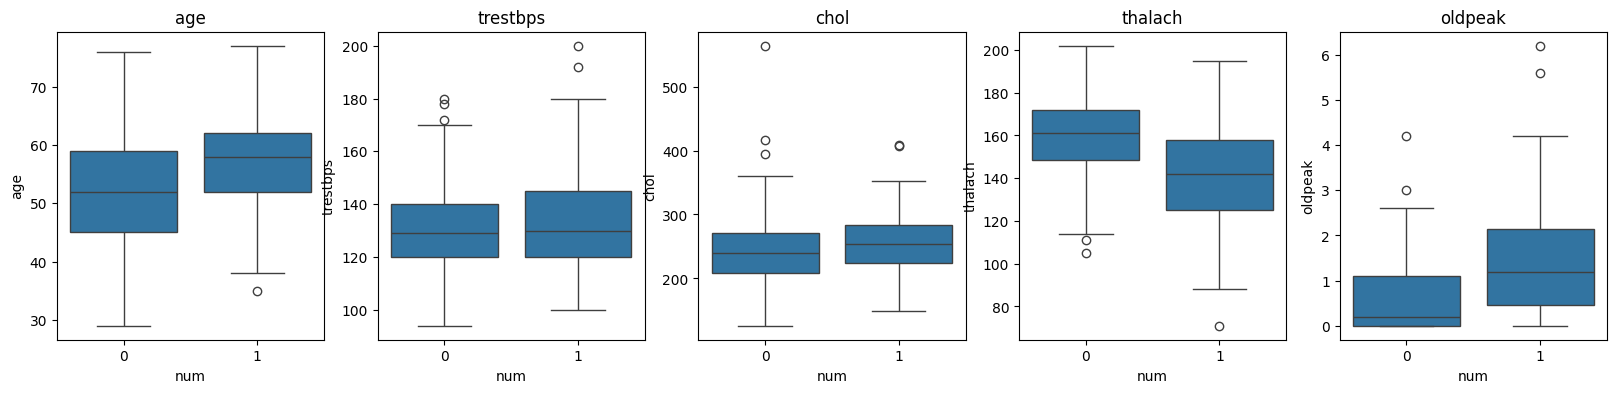

In [7]:
eda.plot_boxplots(df)

### Histograms of continuous features by class

Overlaid histograms confirm what we see in the boxplots: the more separated the two distributions, the more the feature contributes to class separability.

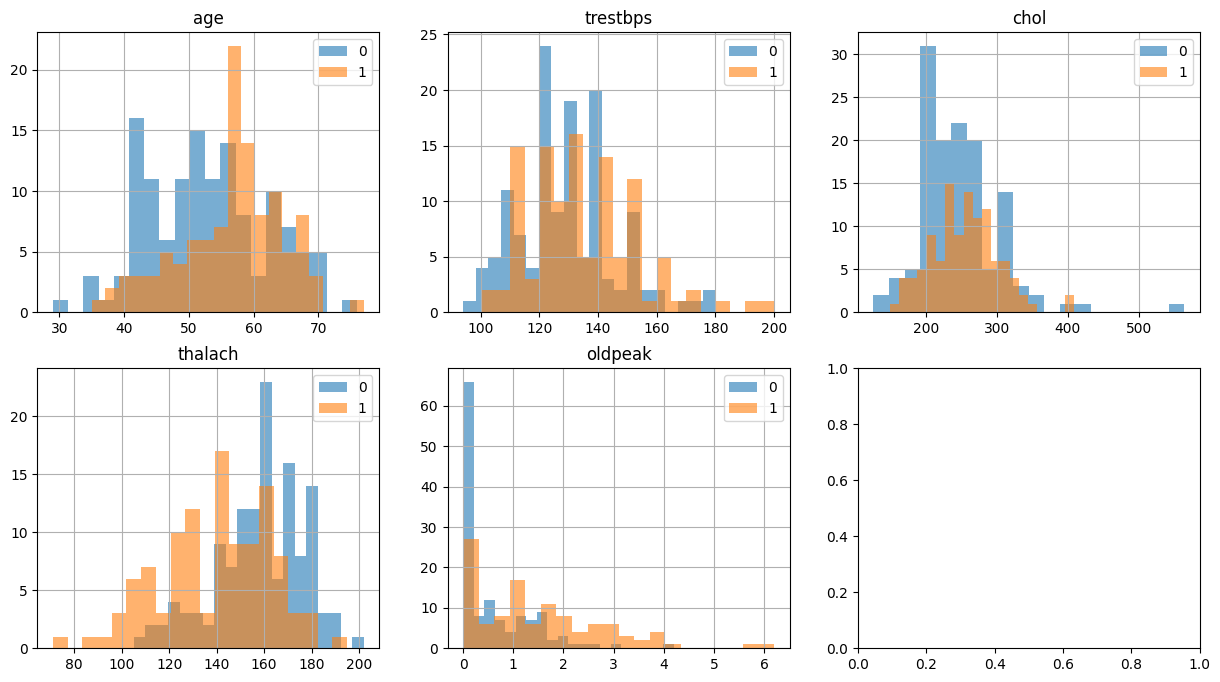

In [8]:
eda.plot_histograms(df)

### Discrete features by class

Counts of binary, categorical, and ordinal features grouped by target. Differences in proportions hint at which categories are associated with disease.

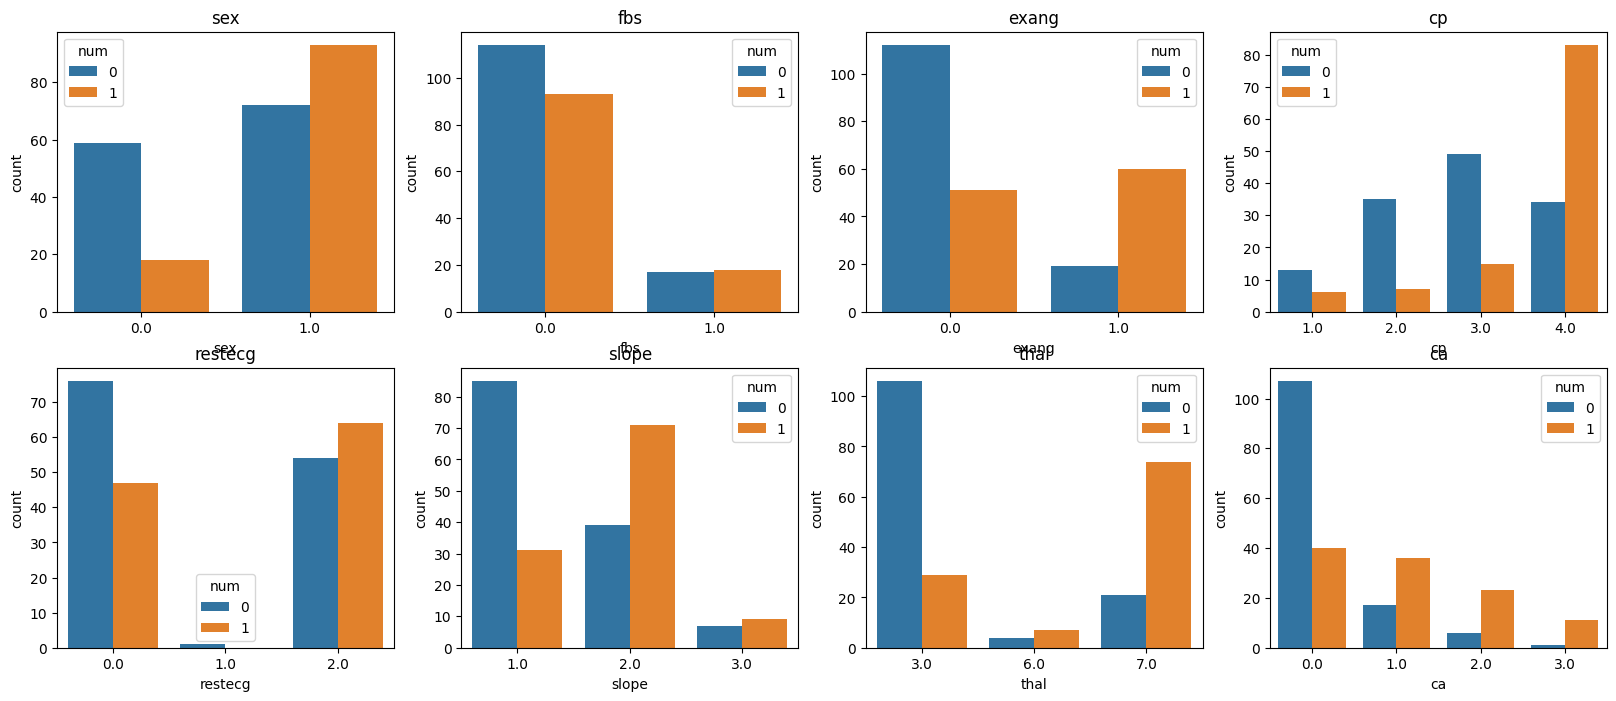

In [9]:
eda.plot_countplots(df)

### Correlation analysis (Spearman)

We use **Spearman** rather than Pearson because the dataset mixes ordinal and continuous features, and Spearman captures monotonic relationships without assuming linearity. The heatmap shows pairwise correlations between features and with the target.

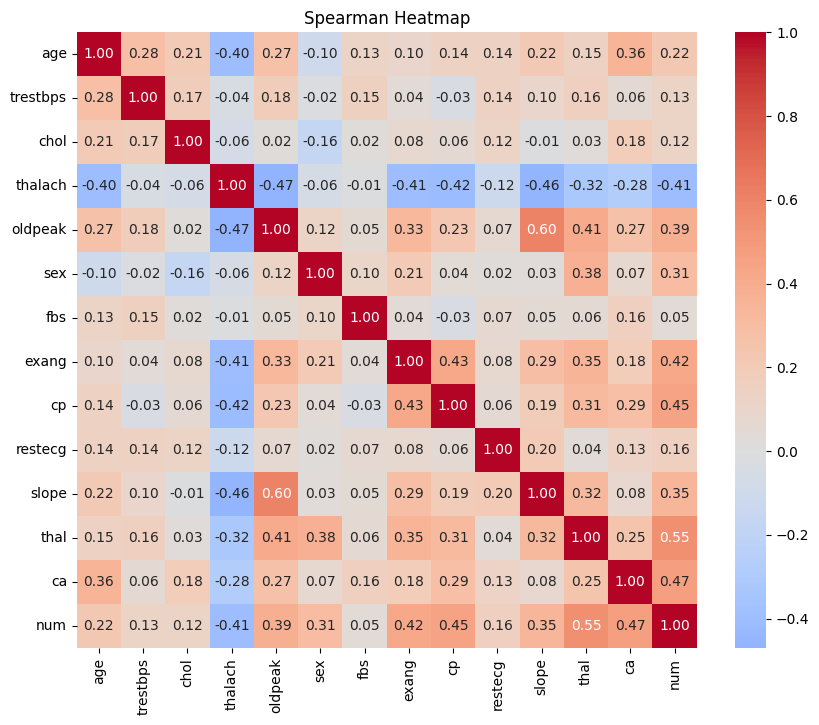

In [10]:
corr = eda.plot_correlation(df)

Top features ranked by absolute Spearman correlation with the target,these are the strongest individual predictors before any feature interaction is considered. The Spearman heatmap confirms that thal, ca, cp, exang and thalach are the strongest predictors. fbs shows near-zero correlation (0.05) with the target and is expected to be removed during feature selection. Notable inter-feature correlations include oldpeak–slope (0.60) and exang–cp (0.43), suggesting some redundancy in the feature set.  On the other hand, thalach shows negative correlations with several heart-disease-related features, such as oldpeak, exang, cp, slope, thal, ca, and the target num. This means that patients with lower maximum heart rate tend to show stronger patterns associated with heart disease.

In [11]:
corr[eda.target].drop(eda.target).abs().sort_values(ascending=False)

thal        0.549055
ca          0.473620
cp          0.451322
exang       0.420280
thalach     0.409741
oldpeak     0.387720
slope       0.347872
sex         0.308342
age         0.219583
restecg     0.160284
trestbps    0.125361
chol        0.116875
fbs         0.045889
Name: num, dtype: float64

### PCA  2D projection

PCA reduces all 13 features to two components, letting us visually check whether the classes are separable. We standardize and impute only for this visualization the modeling pipeline, refits these transformations inside each CV fold to avoid leakage. If the two classes are visibly clustered apart in PC1–PC2 space, even simple linear models should perform reasonably well.

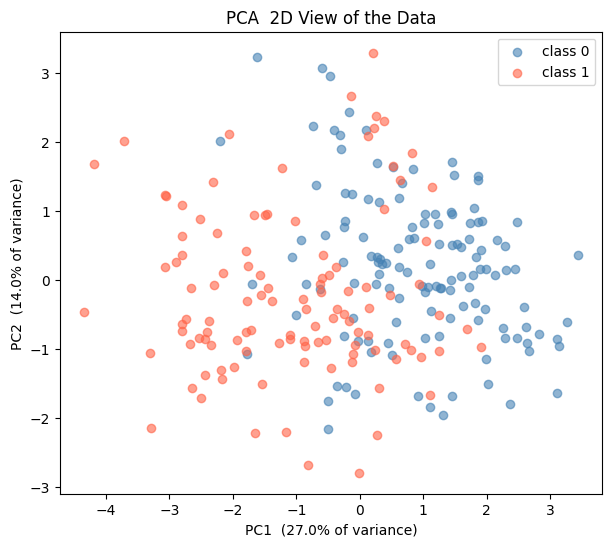

array([0.27013617, 0.14020964])

In [12]:
eda.plot_pca(df)

The 2D PCA projection retains only 41.0% of total variance and reveals substantial class overlap, indicating that linear separation is insufficient. This suggests that the classification problem is more complex. A purely linear model may not be enough to capture the patterns in the data, so non-linear or ensemble models, such as Random Forest, XGBoost, LightGBM, or CatBoost, may be useful because they can capture more complex relationships between features.But we should consider that the dataset is small.SO more complex models may not perform so well.